In [ ]:
from setup import setup, scale_features
from utils import apply_isolation_forest, plot_isolation_forest_pca, plot_isolation_forest_scores

import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [12]:
features = setup()
scaled_features = scale_features(features)

[*********************100%***********************]  9 of 9 completed


Ticker           GLD       IWM       QQQ       SHY       SPY       TLT  \
Date                                                                     
2020-01-03  0.013269 -0.003921 -0.009160  0.000826 -0.007572  0.015400   
2020-01-06  0.010490  0.001333  0.006444 -0.000354  0.003815 -0.005679   
2020-01-07  0.003935 -0.003327 -0.000139  0.000000 -0.002812 -0.004915   
2020-01-08 -0.007502  0.003095  0.007516 -0.000472  0.005330 -0.006611   
2020-01-09 -0.005652  0.001210  0.008474  0.000117  0.006780  0.003510   

Ticker           XLE       XLF       XLK  
Date                                      
2020-01-03 -0.002971 -0.010618 -0.011243  
2020-01-06  0.007782 -0.000651  0.002382  
2020-01-07 -0.002629 -0.006508 -0.000432  
2020-01-08 -0.016472  0.006551  0.010700  
2020-01-09  0.007369  0.006183  0.011336  


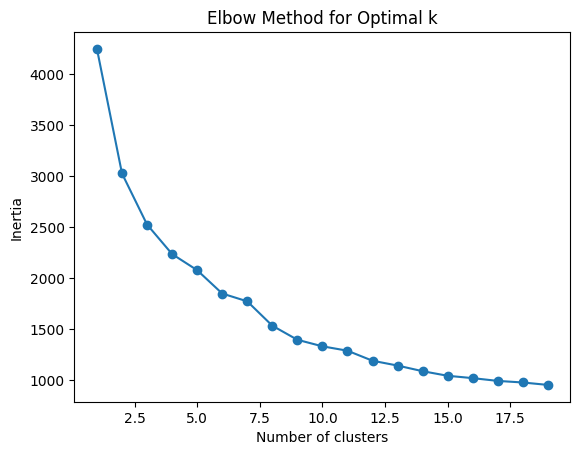

In [13]:
# Run an elbow method to find optimal number of clusters
inertia = []

for k in range(1, 20):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 20), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.show()

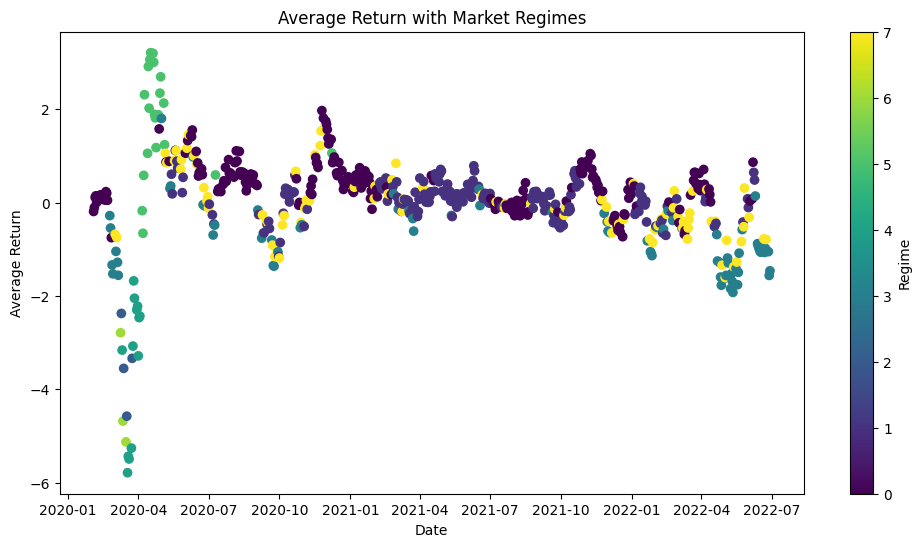

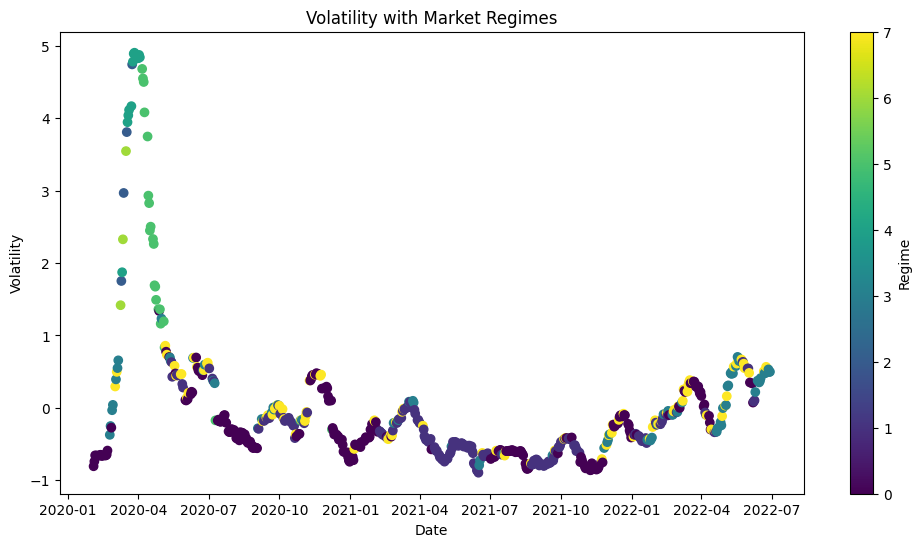

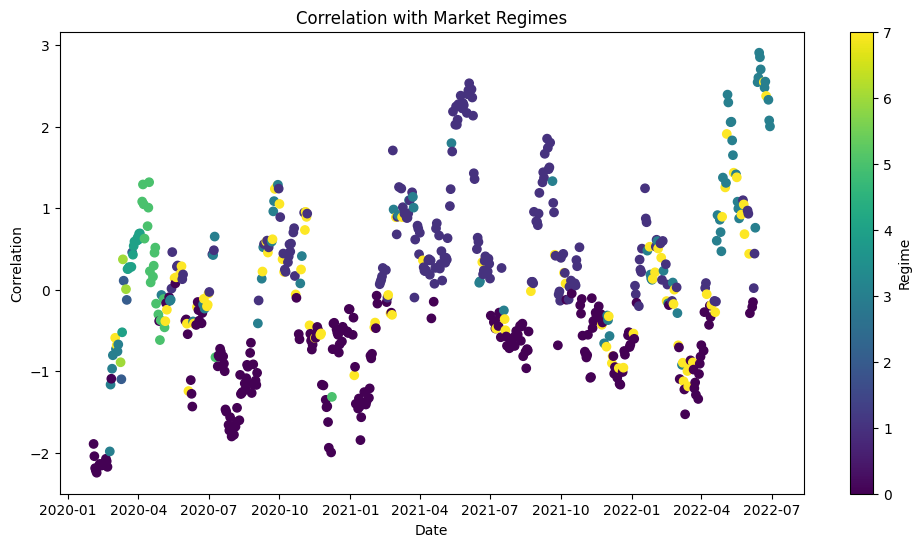

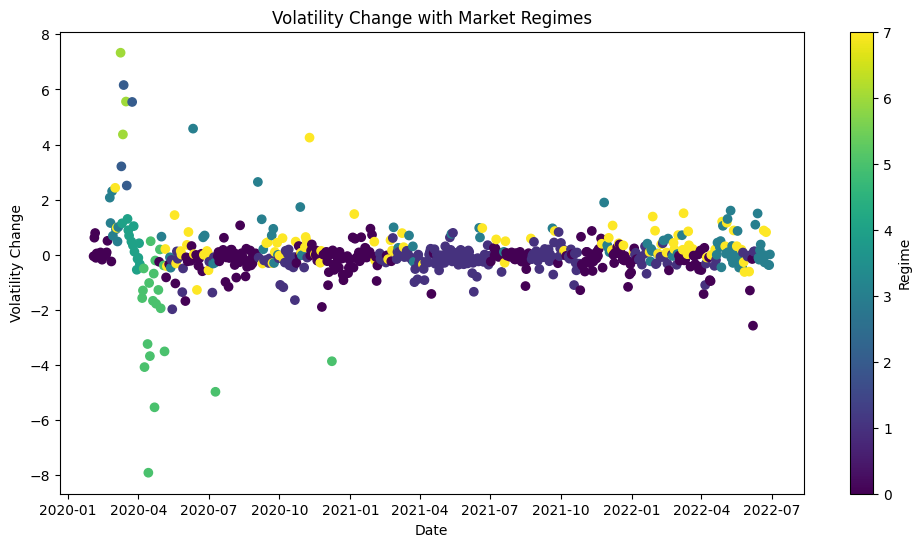

In [14]:
n_clusters = int(input("Enter the number of clusters to use for KMeans from the elbow method: "))

# run k-means clustering
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
regime = kmeans.fit_predict(scaled_features)

features_kmeans = pd.DataFrame(scaled_features, index=features.index, columns=features.columns)
features_kmeans['regime'] = regime

# plot regimes and make colorbar only show whole numbers
plt.figure(figsize=(12, 6))
plt.scatter(features.index, features_kmeans["avg_return"], c=regime, cmap='viridis', marker='o')
plt.title('Average Return with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Average Return')
plt.colorbar(label='Regime', ticks=range(n_clusters))
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(features.index, features_kmeans["volatility"], c=regime, cmap='viridis', marker='o')
plt.title('Volatility with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Volatility')
plt.colorbar(label='Regime', ticks=range(n_clusters))
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(features.index, features_kmeans["correlation"], c=regime, cmap='viridis', marker='o')
plt.title('Correlation with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Correlation')
plt.colorbar(label='Regime', ticks=range(n_clusters))
plt.show()

plt.figure(figsize=(12, 6))
plt.scatter(features.index, features_kmeans["vol_change"], c=regime, cmap='viridis', marker='o')
plt.title('Volatility Change with Market Regimes')
plt.xlabel('Date')
plt.ylabel('Volatility Change')
plt.colorbar(label='Regime', ticks=range(n_clusters))
plt.show()

In [15]:
#calc silhouette score

sil_score = silhouette_score(scaled_features, regime)
print(f"\nSilhouette Score: {sil_score:.2f}")


Silhouette Score: 0.19


In [16]:
features_kmeans.assign(regime=regime).groupby('regime').mean()

,volatility,avg_return,dispersion,correlation,equity_bond_spread,drawdown,vol_change
regime,,,,,,,
0,-0.307413,0.398526,-0.335767,-0.865313,-0.021644,0.418513,-0.155420
1,-0.374308,0.072225,-0.490784,0.707706,-0.022321,0.311862,-0.163062
2,3.318868,-3.458697,4.824123,-0.162847,4.465566,-4.253714,4.357374
3,0.087937,-0.765783,0.540927,0.701855,-1.057776,-0.845619,0.496454
4,4.381685,-3.431987,1.783084,0.410261,-0.758973,-4.031572,0.407705
5,2.246877,1.779043,0.731811,0.224445,0.487912,0.371618,-2.302732
6,2.431257,-4.196992,6.610058,-0.169670,-5.616418,-4.986763,5.753951
7,0.032718,-0.099288,0.465866,0.060882,0.986793,-0.072465,0.372184


In [17]:
features_kmeans["future_return"] = features_kmeans["avg_return"].shift(-1)
features_kmeans.assign(regime=regime).groupby('regime')["future_return"].mean()

regime
0    0.368790
1    0.069701
2   -4.285326
3   -0.712536
4   -3.137480
5    1.758759
6   -3.499665
7   -0.096351
Name: future_return, dtype: float64

In [18]:
labels, best_params, score = apply_isolation_forest(scaled_features)
print(f"Best contamination={best_params[0]}, n_estimators={best_params[1]}")
print(f"Silhouette Score: {score:.4f}")
print(f"Normal: {(labels == 1).sum()}, Anomalies: {(labels == -1).sum()}")

Best contamination=0.01, n_estimators=100
Silhouette Score: 0.7562
Normal: 600, Anomalies: 7


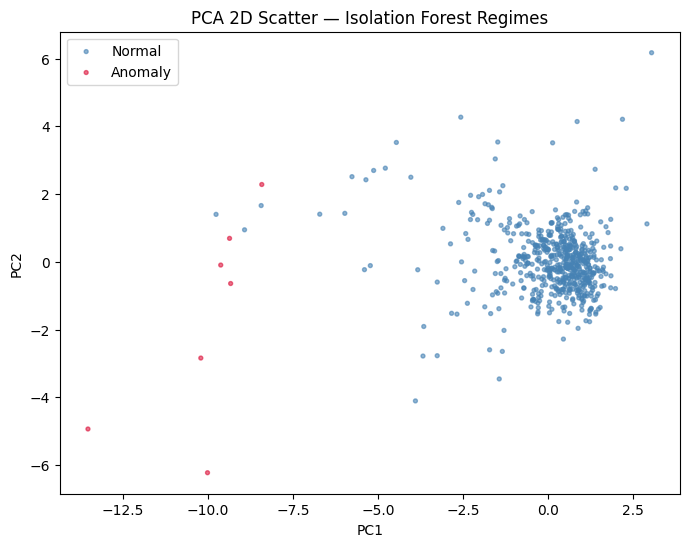

In [19]:
plot_isolation_forest_pca(scaled_features, labels)

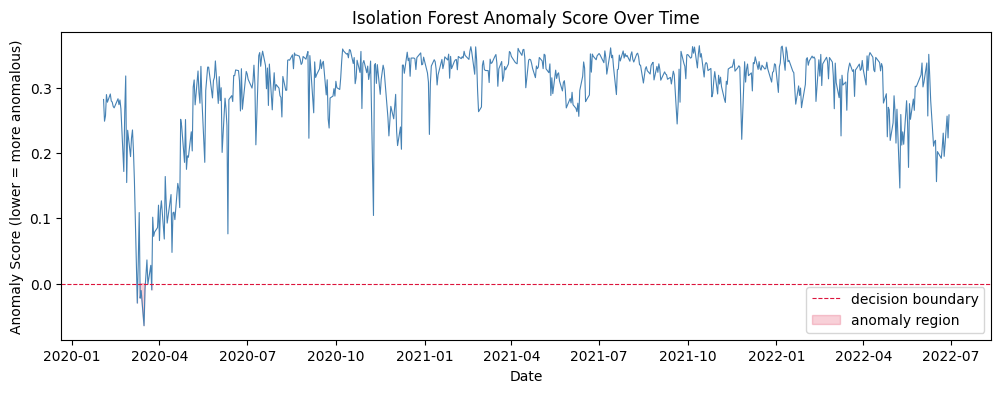

In [20]:
plot_isolation_forest_scores(scaled_features, features.index, best_params[0], best_params[1])